# Лабораторная работа №5
  
## Тема: Кластеризация (k-средних, иерархическая)
  
## Цель работы: Ознакомиться с методами кластеризации модуля Sklearn.

**Студент:** Магомедов Имран Борисович  
**Группа:** ПИЖ-Б-О-22-1  
**Курс/Семестр:** 4/8  

## Методика и порядок выполнения работы

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import random
from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering
from sklearn.metrics.pairwise import pairwise_distances_argmin
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs

### Загрузка данных

2. Загрузка данных

In [2]:
data = pd.read_csv('/content/drive/MyDrive/NCFU/ОиАБД/Отчеты/Лабораторная работа №5/data/iris.data', header=None)
print("Исходные данные:")
print(data.head())
print(f"\nРазмер данных: {data.shape}")

# Отделяем признаки от меток (последний столбец - классы)
no_labeled_data = data.iloc[:, :4].to_numpy()
true_labels = data.iloc[:, 4].to_numpy()
print(f"Признаки: {no_labeled_data.shape[1]}")
print(f"Количество наблюдений: {no_labeled_data.shape[0]}")

Исходные данные:
     0    1    2    3            4
0  5.1  3.5  1.4  0.2  Iris-setosa
1  4.9  3.0  1.4  0.2  Iris-setosa
2  4.7  3.2  1.3  0.2  Iris-setosa
3  4.6  3.1  1.5  0.2  Iris-setosa
4  5.0  3.6  1.4  0.2  Iris-setosa

Размер данных: (150, 5)
Признаки: 4
Количество наблюдений: 150


### K-means

1. Кластеризация методом k-средних

In [3]:
k_means = KMeans(init='k-means++', n_clusters=3, n_init=15, random_state=42)
k_means.fit(no_labeled_data)

KMeans(n_clusters=3, n_init=15, random_state=42)

2. Получение центров кластеров и меток

In [4]:
k_means_cluster_centers = k_means.cluster_centers_
k_means_labels = pairwise_distances_argmin(no_labeled_data, k_means_cluster_centers)
print(f"Центры кластеров:\n{k_means_cluster_centers}")
print(f"Распределение по кластерам: {np.bincount(k_means_labels)}")

Центры кластеров:
[[5.9016129  2.7483871  4.39354839 1.43387097]
 [5.006      3.418      1.464      0.244     ]
 [6.85       3.07368421 5.74210526 2.07105263]]
Распределение по кластерам: [62 50 38]


3. Построение результатов для пар признаков

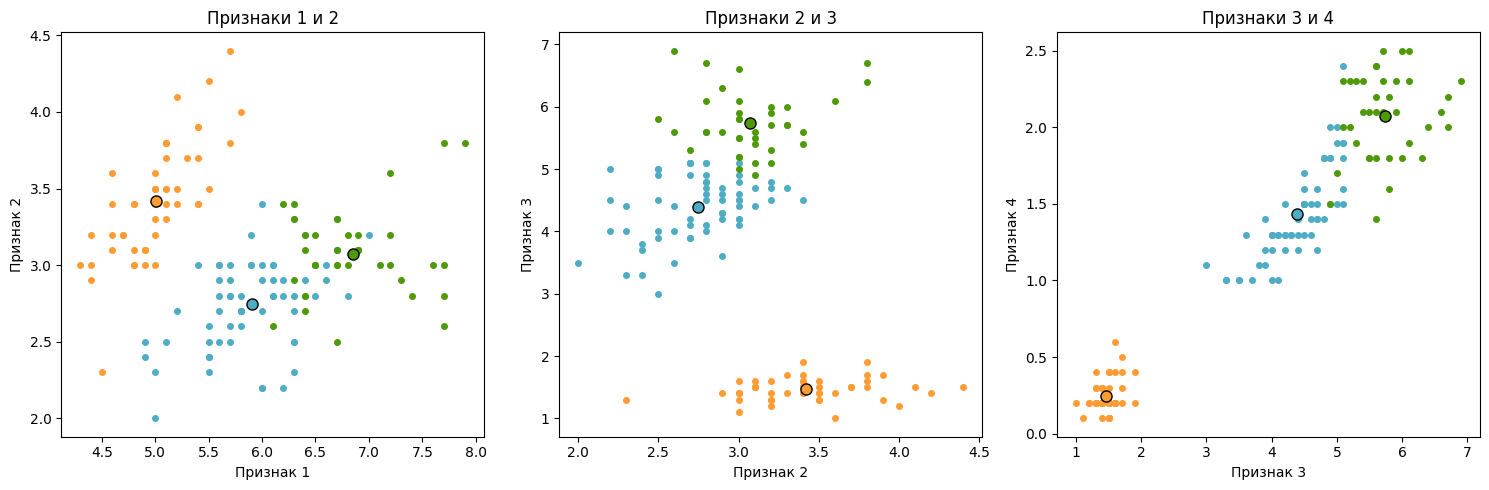

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#4EACC5', '#FF9C34', '#4E9A06']

pairs = [(0, 1), (1, 2), (2, 3)]
pair_names = [('Признак 1', 'Признак 2'), ('Признак 2', 'Признак 3'), ('Признак 3', 'Признак 4')]

for idx, (i, j) in enumerate(pairs):
    for k in range(3):
        my_members = k_means_labels == k
        cluster_center = k_means_cluster_centers[k]
        axes[idx].plot(no_labeled_data[my_members, i],
                       no_labeled_data[my_members, j],
                       'o', markerfacecolor=colors[k],
                       markersize=4, color=colors[k], linestyle='None')
        axes[idx].plot(cluster_center[i], cluster_center[j], 'o',
                      markerfacecolor=colors[k], markeredgecolor='k',
                      markersize=8)
    axes[idx].set_xlabel(pair_names[idx][0])
    axes[idx].set_ylabel(pair_names[idx][1])
    axes[idx].set_title(f'Признаки {i+1} и {j+1}')

plt.tight_layout()
plt.show()

Наилучшее разделение наблюдается по признакам 3 и 4 (длина и ширина лепестка)

Признаки 1 и 2 (длина и ширина чашелистика) дают больше перекрытия кластеров

Параметр n_init: количество запусков алгоритма с разными начальными центрами

Чем больше n_init, тем выше вероятность найти глобальный оптимум

4. Уменьшение размерности до 2 с помощью PCA


=== Визуализация кластеров в пространстве PCA ===


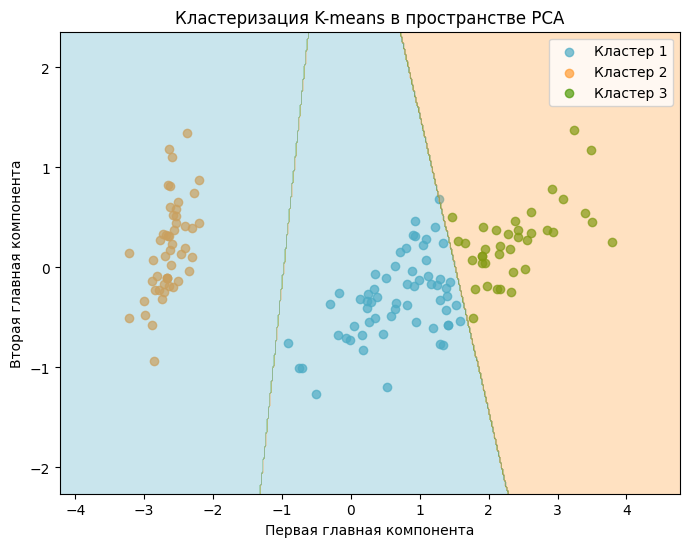

In [6]:
print("\n=== Визуализация кластеров в пространстве PCA ===")
pca = PCA(n_components=2)
data_pca = pca.fit_transform(no_labeled_data)

plt.figure(figsize=(8, 6))
for k in range(3):
    my_members = k_means_labels == k
    plt.scatter(data_pca[my_members, 0], data_pca[my_members, 1],
               c=colors[k], label=f'Кластер {k+1}', alpha=0.7)

# Построение границ кластеров
h = 0.02
x_min, x_max = data_pca[:, 0].min() - 1, data_pca[:, 0].max() + 1
y_min, y_max = data_pca[:, 1].min() - 1, data_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Классификация точек сетки
Z = k_means.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, colors=colors)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Кластеризация K-means в пространстве PCA')
plt.legend()
plt.show()

5. Исследование параметра init

In [7]:
print("\n=== Исследование параметра init ===")

# init='random'
kmeans_random = KMeans(init='random', n_clusters=3, n_init=1, random_state=42)
kmeans_random.fit(no_labeled_data)
print(f"init='random': центры кластеров:\n{kmeans_random.cluster_centers_}")

# Ручной выбор центров
manual_centers = np.array([[5.0, 3.5, 1.5, 0.2],
                           [6.0, 3.0, 4.0, 1.5],
                           [6.5, 3.0, 5.5, 2.0]])
kmeans_manual = KMeans(init=manual_centers, n_clusters=3, n_init=1)
kmeans_manual.fit(no_labeled_data)
print(f"\ninit (ручной): центры кластеров:\n{kmeans_manual.cluster_centers_}")


=== Исследование параметра init ===
init='random': центры кластеров:
[[5.006      3.418      1.464      0.244     ]
 [5.9016129  2.7483871  4.39354839 1.43387097]
 [6.85       3.07368421 5.74210526 2.07105263]]

init (ручной): центры кластеров:
[[5.006      3.418      1.464      0.244     ]
 [5.88360656 2.74098361 4.38852459 1.43442623]
 [6.85384615 3.07692308 5.71538462 2.05384615]]


6. Метод локтя для определения оптимального количества кластеров


=== Метод локтя ===


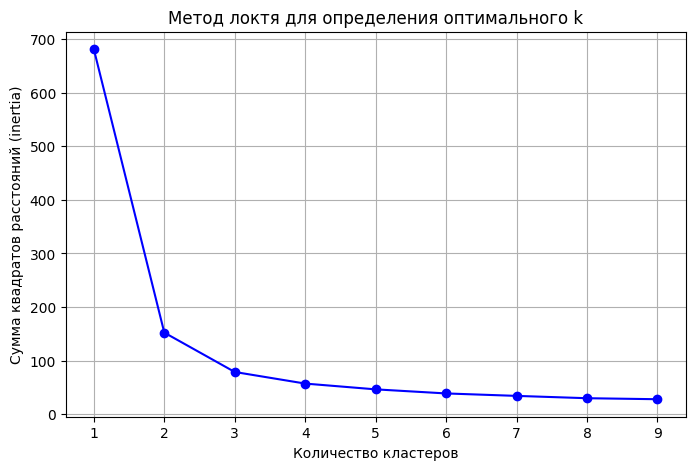

Оптимальное количество кластеров: 3 (изгиб на графике)


In [8]:
print("\n=== Метод локтя ===")
inertias = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(no_labeled_data)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Количество кластеров')
plt.ylabel('Сумма квадратов расстояний (inertia)')
plt.title('Метод локтя для определения оптимального k')
plt.grid()
plt.show()

print("Оптимальное количество кластеров: 3 (изгиб на графике)")

7. Пакетная кластеризация k-средних


=== Пакетная кластеризация (MiniBatchKMeans) ===
Количество точек, попавших в разные кластеры: 99


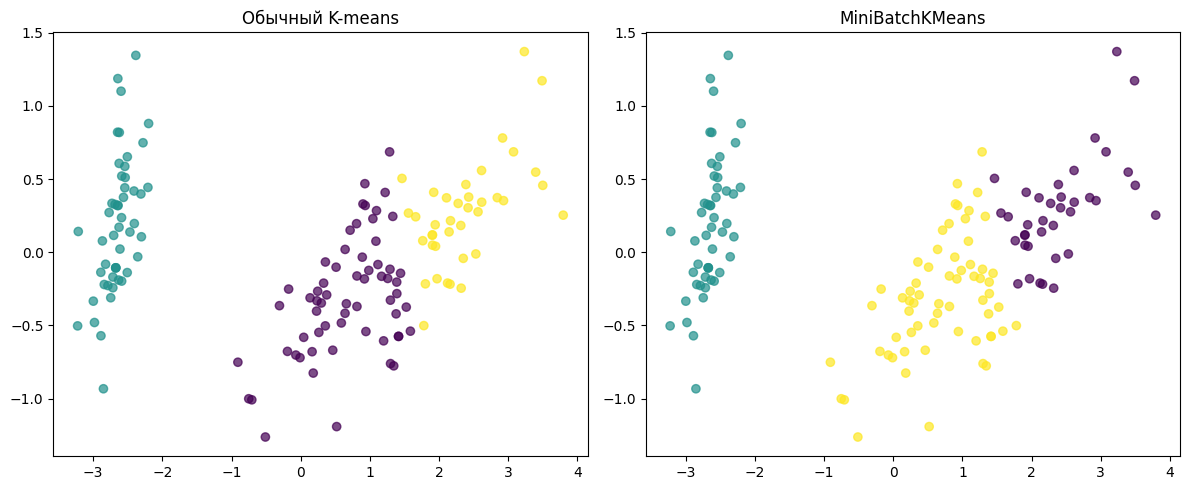

In [9]:
print("\n=== Пакетная кластеризация (MiniBatchKMeans) ===")
mini_kmeans = MiniBatchKMeans(n_clusters=3, batch_size=50, n_init=10, random_state=42)
mini_kmeans.fit(no_labeled_data)
mini_labels = mini_kmeans.labels_

# Сравнение обычного и пакетного методов
different_points = (k_means_labels != mini_labels)
print(f"Количество точек, попавших в разные кластеры: {np.sum(different_points)}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=k_means_labels, cmap='viridis', alpha=0.7)
plt.title('Обычный K-means')

plt.subplot(1, 2, 2)
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=mini_labels, cmap='viridis', alpha=0.7)
plt.title('MiniBatchKMeans')

plt.tight_layout()
plt.show()

Отличия MiniBatchKMeans от KMeans:
- Использует мини-пакеты данных на каждой итерации
- Быстрее работает на больших данных
- Может давать немного отличающиеся результаты
- Требует меньше памяти

### Иерархическая кластеризация

1. Иерархическая кластеризация

In [10]:
hier = AgglomerativeClustering(n_clusters=3, linkage='average')
hier_labels = hier.fit_predict(no_labeled_data)

2. Отображение результатов

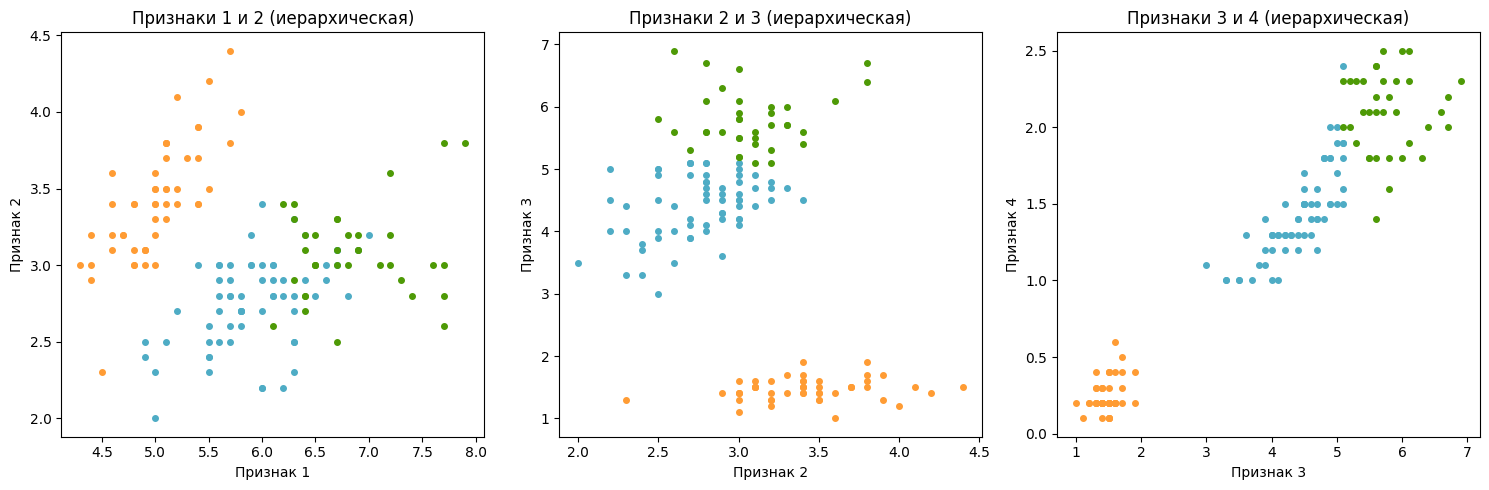

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (i, j) in enumerate(pairs):
    for k in range(3):
        my_members = hier_labels == k
        axes[idx].plot(no_labeled_data[my_members, i],
                       no_labeled_data[my_members, j],
                       'o', markerfacecolor=colors[k],
                       markersize=4, color=colors[k], linestyle='None')
    axes[idx].set_xlabel(pair_names[idx][0])
    axes[idx].set_ylabel(pair_names[idx][1])
    axes[idx].set_title(f'Признаки {i+1} и {j+1} (иерархическая)')

plt.tight_layout()
plt.show()

K-means:
- Требует задать количество кластеров
- Ищет сферические кластеры
- Чувствителен к начальным центрам

Иерархическая кластеризация:
- Не требует задавать количество кластеров (можно обрезать дендрограмму)
- Может находить кластеры произвольной формы
- Результат зависит от выбранной метрики и метода связи
- Строит иерархическую структуру кластеров

3. Исследование различного количества кластеров

In [12]:
for n in range(2, 6):
    hier_n = AgglomerativeClustering(n_clusters=n, linkage='average')
    labels_n = hier_n.fit_predict(no_labeled_data)
    print(f"Кластеров = {n}: распределение {np.bincount(labels_n)}")

Кластеров = 2: распределение [100  50]
Кластеров = 3: распределение [64 50 36]
Кластеров = 4: распределение [36 50 60  4]
Кластеров = 5: распределение [50 12 60  4 24]


4. Построение дендрограммы

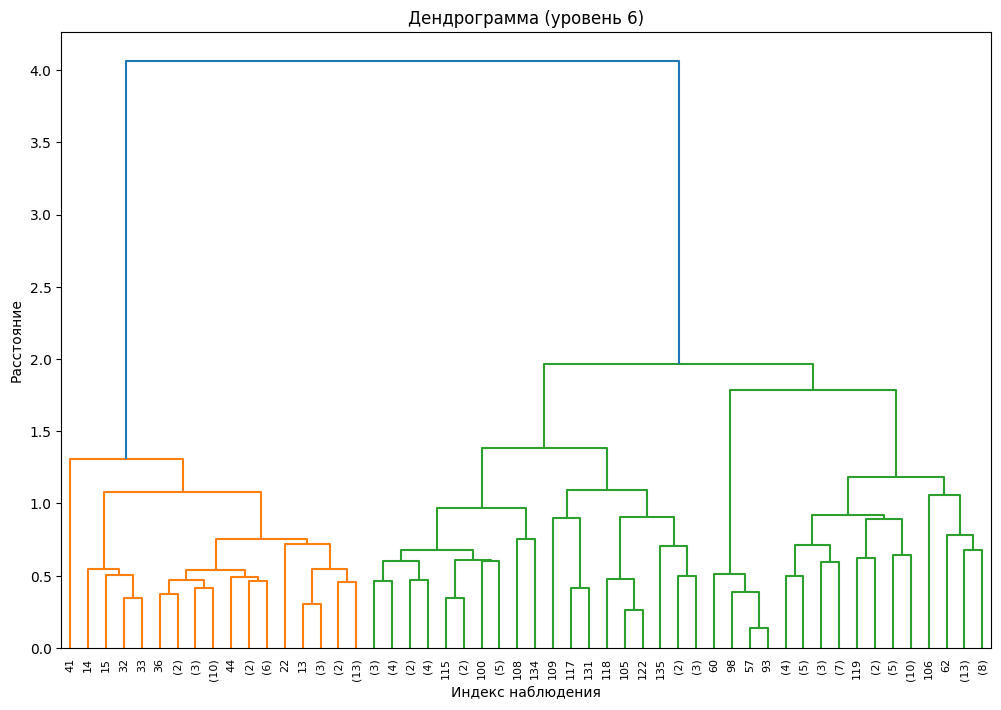

In [13]:
linkage_matrix = linkage(no_labeled_data, method='average')

plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, truncate_mode='level', p=6, leaf_rotation=90, leaf_font_size=8)
plt.title('Дендрограмма (уровень 6)')
plt.xlabel('Индекс наблюдения')
plt.ylabel('Расстояние')
plt.show()

5-7. Кластеризация двух колец

In [14]:
# Генерация данных
data1 = np.zeros([250, 2])
for i in range(250):
    r = random.uniform(1, 3)
    a = random.uniform(0, 2 * math.pi)
    data1[i, 0] = r * math.sin(a)
    data1[i, 1] = r * math.cos(a)

data2 = np.zeros([500, 2])
for i in range(500):
    r = random.uniform(5, 9)
    a = random.uniform(0, 2 * math.pi)
    data2[i, 0] = r * math.sin(a)
    data2[i, 1] = r * math.cos(a)

ring_data = np.vstack((data1, data2))

6. Иерархическая кластеризация колец

In [15]:
hier_ring = AgglomerativeClustering(n_clusters=2, linkage='ward')
hier_ring_labels = hier_ring.fit_predict(ring_data)

7. Вывод результатов

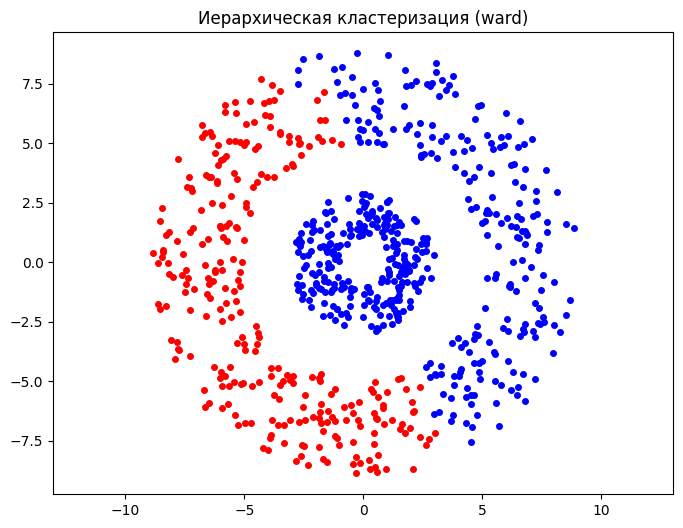

In [16]:
plt.figure(figsize=(8, 6))
my_members = hier_ring_labels == 0
plt.plot(ring_data[my_members, 0], ring_data[my_members, 1], 'o',
         color='red', markersize=4, linestyle='None')
my_members = hier_ring_labels == 1
plt.plot(ring_data[my_members, 0], ring_data[my_members, 1], 'o',
         color='blue', markersize=4, linestyle='None')
plt.title('Иерархическая кластеризация (ward)')
plt.axis('equal')
plt.show()

8. Исследование различных методов linkage

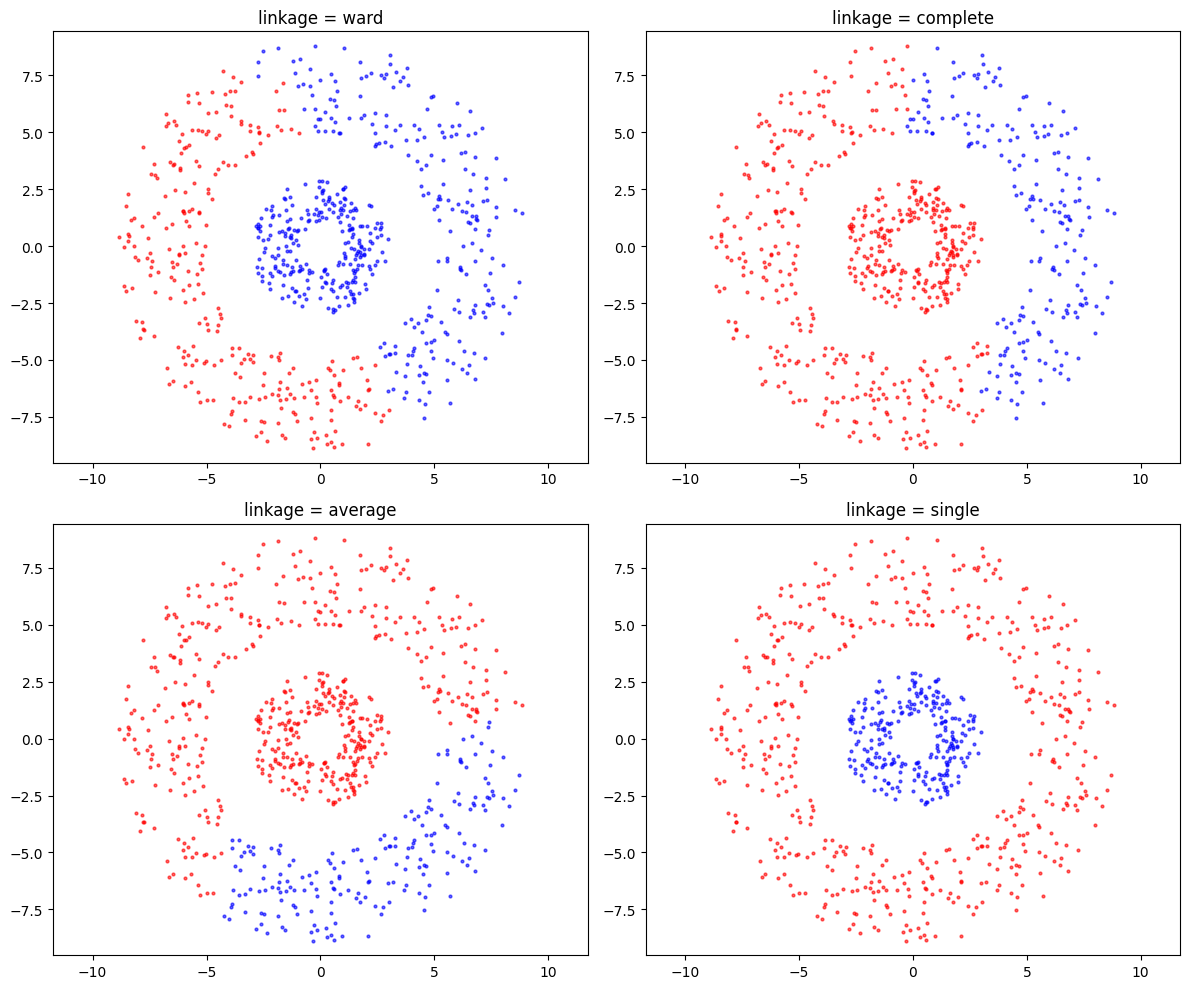

In [17]:
linkage_methods = ['ward', 'complete', 'average', 'single']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, method in enumerate(linkage_methods):
    hier_test = AgglomerativeClustering(n_clusters=2, linkage=method)
    labels_test = hier_test.fit_predict(ring_data)

    axes[idx].scatter(ring_data[labels_test == 0, 0], ring_data[labels_test == 0, 1],
                     c='red', s=4, alpha=0.6)
    axes[idx].scatter(ring_data[labels_test == 1, 0], ring_data[labels_test == 1, 1],
                     c='blue', s=4, alpha=0.6)
    axes[idx].set_title(f'linkage = {method}')
    axes[idx].axis('equal')

plt.tight_layout()
plt.show()

Анализ методов linkage:
- single: лучше всего разделяет кольца, но чувствителен к шуму
- complete: также хорошо разделяет кольца
- average: компромиссный вариант, работает хорошо
- ward: минимизирует внутрикластерную дисперсию, хорошо для сферических кластеров

Для данных в виде колец лучше всего работают методы single и complete

Для сферических кластеров лучше подходит ward

## Выводы

В ходе работы были изучены методы кластеризации K-means и иерархическая кластеризация. На данных Iris K-means показал хорошее разделение, особенно по признакам лепестка. Метод локтя подтвердил оптимальность трех кластеров. Исследованы параметры init и n_init, показано влияние начальных центров. Пакетная кластеризация MiniBatchKMeans быстрее, но может давать незначительные отличия.

Иерархическая кластеризация построила дендрограмму и показала возможность визуализации иерархической структуры. На данных в виде двух колец исследованы методы linkage: single и complete лучше разделяют кольца, ward предпочтителен для сферических кластеров.